In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../data/feature_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

display(df.head())



Dataset loaded successfully!
Rows: 105971
Columns: 23

Columns:
['timestamp_ms', 'ax', 'ay', 'az', 'gyro_yaw', 'gyro_pitch', 'gyro_roll', 'gps_lat', 'gps_lon', 'gps_speed', 'vehicle_speed', 'vehicle_heading', 'accel_magnitude', 'gyro_magnitude', 'accel_change', 'gyro_change', 'ax_change', 'ay_change', 'az_change', 'gyro_yaw_change', 'gyro_pitch_change', 'gyro_roll_change', 'dt']


,timestamp_ms,ax,ay,az,gyro_yaw,gyro_pitch,gyro_roll,gps_lat,gps_lon,gps_speed,...,gyro_magnitude,accel_change,gyro_change,ax_change,ay_change,az_change,gyro_yaw_change,gyro_pitch_change,gyro_roll_change,dt
0,210,1.5948,-0.5938,9.2523,-0.0484,-0.0973,0.0266,52.38674,-1.535683,0.0,...,0.111881,-0.466847,0.069639,0.5193,0.4094,-0.5119,-0.0550,-0.0734,0.0608,0.100
1,312,1.0366,-0.2979,9.6744,0.1012,0.0351,0.1326,52.38674,-1.535683,0.0,...,0.170459,0.326837,0.058578,-0.5582,0.2959,0.4221,0.1496,0.1324,0.1060,0.102
2,411,0.9370,-1.3685,9.9196,0.0526,-0.1466,0.0997,52.38674,-1.535683,0.0,...,0.184928,0.322961,0.014469,-0.0996,-1.0706,0.2452,-0.0486,-0.1817,-0.0329,0.099
3,510,0.9962,-0.7901,9.6631,0.0097,0.0434,0.0590,52.38674,-1.535683,0.0,...,0.073883,-0.310904,-0.111045,0.0592,0.5784,-0.2565,-0.0429,0.1900,-0.0407,0.099
4,610,1.1587,-0.7392,9.7115,0.0099,0.0151,0.0020,52.38674,-1.535683,0.0,...,0.018166,0.061881,-0.055716,0.1625,0.0509,0.0484,0.0002,-0.0283,-0.0570,0.100


In [ ]:
print("Missing values:")
display(df.isnull().sum())

print("\nDataset statistics:")
display(df.describe().T)

Missing values:


timestamp_ms         0
ax                   0
ay                   0
az                   0
gyro_yaw             0
gyro_pitch           0
gyro_roll            0
gps_lat              0
gps_lon              0
gps_speed            0
vehicle_speed        0
vehicle_heading      0
accel_magnitude      0
gyro_magnitude       0
accel_change         0
gyro_change          0
ax_change            0
ay_change            0
az_change            0
gyro_yaw_change      0
gyro_pitch_change    0
gyro_roll_change     0
dt                   0
dtype: int64


Dataset statistics:


,count,mean,std,min,25%,50%,75%,max
timestamp_ms,105971.0,2.724194e+06,1.648451e+06,210.000000,1.327502e+06,2.652128e+06,3.976751e+06,6.175975e+06
ax,105971.0,-1.738298e-01,1.246069e+00,-39.649600,-6.913500e-01,-7.160000e-02,4.189000e-01,1.823630e+01
ay,105971.0,-7.016379e-02,1.273969e+00,-39.361200,-4.876000e-01,3.000000e-04,4.891000e-01,1.280860e+01
az,105971.0,9.854227e+00,6.295836e-01,-19.576900,9.579800e+00,9.851300e+00,1.012160e+01,5.944610e+01
gyro_yaw,105971.0,-2.044905e-03,9.439367e-02,-9.810800,-2.360000e-02,-1.800000e-03,1.880000e-02,5.873300e+00
gyro_pitch,105971.0,-1.842298e-02,1.744687e-01,-8.448500,-3.380000e-02,2.500000e-03,3.510000e-02,1.266350e+01
gyro_roll,105971.0,1.178807e-03,7.765732e-02,-3.847200,-2.120000e-02,-5.000000e-04,2.190000e-02,9.716900e+00
gps_lat,105971.0,5.242443e+01,3.129701e-02,52.357857,5.240258e+01,5.242999e+01,5.244862e+01,5.247920e+01
gps_lon,105971.0,-1.502473e+00,4.535981e-02,-1.588746,-1.529287e+00,-1.501908e+00,-1.471319e+00,-1.378485e+00
gps_speed,105971.0,9.966266e+00,5.554630e+00,0.000000,6.410000e+00,1.019000e+01,1.342000e+01,2.702000e+01


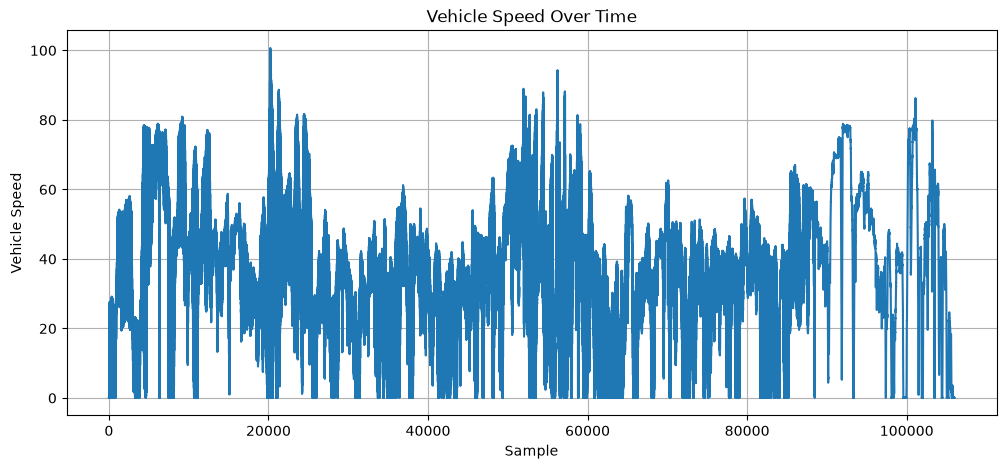

In [3]:
plt.figure(figsize=(12, 5))

plt.plot(df["vehicle_speed"].values)

plt.title("Vehicle Speed Over Time")
plt.xlabel("Sample")
plt.ylabel("Vehicle Speed")
plt.grid(True)

plt.show()

In [4]:
features = [
    "ax",
    "ay",
    "az",
    "gyro_yaw",
    "gyro_pitch",
    "gyro_roll",
    "accel_magnitude",
    "gyro_magnitude",
    "accel_change",
    "gyro_change"
]

target = "vehicle_speed"

X = df[features]
y = df[target]

print("Features:", features)
print("Target:", target)
print("Samples:", len(X))

Features: ['ax', 'ay', 'az', 'gyro_yaw', 'gyro_pitch', 'gyro_roll', 'accel_magnitude', 'gyro_magnitude', 'accel_change', 'gyro_change']
Target: vehicle_speed
Samples: 105971


In [5]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 84776
Testing samples: 21195


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Small prototype dataset
train_size = 10000
test_size = 3000

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_test = X.iloc[train_size:train_size + test_size]
y_test = y.iloc[train_size:train_size + test_size]

print("Training:", len(X_train))
print("Testing:", len(X_test))

model = ExtraTreesRegressor(
    n_estimators=20,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("Training AI model...")

model.fit(X_train, y_train)

print("MODEL TRAINED ✅")

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n🔥 AI SPEED MODEL")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Use a small dataset for the prototype
train_size = 10000
test_size = 3000

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_test = X.iloc[train_size:train_size + test_size]
y_test = y.iloc[train_size:train_size + test_size]

model = LinearRegression()

print("Training model...")

model.fit(X_train, y_train)

print("MODEL TRAINED ✅")

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nAI SPEED MODEL")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")